In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import mdtraj as md
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from docking_tools import trajectory_analysis, plotting
    HAS_DOCKING_TOOLS = True
except ImportError:
    print("WARNING: docking_tools not found - interaction fingerprints disabled")
    HAS_DOCKING_TOOLS = False

In [ ]:
# ================================================================
# Parameteres and indices for atoms
# ================================================================
CONTACT_ANG = 6.0
CONTACT_NM  = CONTACT_ANG / 10.0
N_CLUS      = 20

LIGAND_RESID_PAPER = 21

LIG_HEAVY_PAPER = [294, 295, 296, 297, 298, 299, 300, 301, 302, 303,
                    304, 305, 306, 307, 308, 309, 310, 311, 312, 313,
                    316, 317]
LIG_H_PAPER = [314, 315, 318, 319, 320, 321, 322, 323, 324, 325,
                326, 327, 328, 329, 330, 331, 332, 333, 334, 335,
                336, 337]
assert len(LIG_HEAVY_PAPER) == 22
assert len(LIG_H_PAPER) == 22

# H-bond donors: NH2 group (N=312, two H's at 314, 315)
LIG_HBOND_DONORS_PAPER = [[312, 314], [312, 315]]
LIG_POS_CHARGES_PAPER  = [312]

# Aromatic rings (auto-detected geometry)
RING_BENZENE_PAPER = [300, 301, 302, 303, 304, 305]
RING_5N1_PAPER     = [297, 298, 299, 300, 301]

HYDROGEN_TYPES = {'HD', 'H'}

In [ ]:
# ================================================================
# 1.  Paths
# ================================================================

PAPER_PDB = '/home/zhihanz/data/DiffDock_copy/data/anjali/ligand47/AutoDock_apo.pdb'
PAPER_XTC = '/home/zhihanz/data/DiffDock_copy/data/anjali/ligand47/AutoDock_apo.xtc'


VINA_RESULTS_DIR  = '/home/zhihanz/data/autodock_vina/hpc_results/05042026/docking_best_47'
VINA_FILE_PATTERN = "frame_*_47_best_out.pdbqt"
PROT_FRAMES_DIR   = '/home/zhihanz/data/autodock_vina/protein_frames/protein_frames_apo'


DD_TRAJ_FILE = '/home/zhihanz/data/DiffDock_copy/data/anjali/ligand47/DiffDock_apo_fixed.xtc'
DD_PDB       = '/home/zhihanz/data/DiffDock_copy/data/anjali/ligand47/DiffDock_apo_H.pdb'
DD_CLUS_COUNT= '/home/zhihanz/data/DiffDock_copy/data/anjali/ligand47/DiffDock_apo_clus_count.txt'
MD_APO_CLUS  = '/home/zhihanz/data/DiffDock_copy/data/anjali/ligand47/AutoDock_apo_clus_count.txt'

# DiffDockL indices 
LIGAND_RESID_DD     = 20
RING_IMIDAZOLE_DD   = [297, 298, 299, 300, 301]
RING_BENZENE_DD     = [300, 301, 302, 303, 304, 305]
RING_TRIAZOLE_DD    = [310, 311, 312, 313, 314]
LIG_HBOND_DONORS_DD = [[296, 329], [313, 351]]
LIG_POS_CHARGES_DD  = [313]

OUT_DIR = Path('/home/zhihanz/data/autodock_vina/analysis_paper_compatible')
OUT_DIR.mkdir(exist_ok=True, parents=True)

In [ ]:
# ================================================================
# 2.  Helpers
# ================================================================
def compute_bound_fraction_uniform(traj, lig_atom_idx, n_res, cutoff_nm=0.6):
    bound = np.zeros((traj.n_frames, n_res), dtype=float)
    lig_xyz = traj.xyz[:, np.asarray(lig_atom_idx, dtype=int), :]
    for ri, res in enumerate(traj.top.residues):
        if not res.is_protein:
            continue
        if ri >= n_res:
            break
        prot_idx = [a.index for a in res.atoms]
        prot_xyz = traj.xyz[:, prot_idx, :]
        diff = prot_xyz[:, :, np.newaxis, :] - lig_xyz[:, np.newaxis, :, :]
        dists = np.sqrt((diff ** 2).sum(axis=-1))
        min_d = dists.reshape(traj.n_frames, -1).min(axis=1)
        bound[:, ri] = (min_d < cutoff_nm).astype(float)
    return bound.mean(axis=0)


def parse_vina_pdbqt_full(filepath):
    """Parse Vina pdbqt - returns frame_id, score, heavy coords, polar H coords."""
    fname = Path(filepath).stem
    frame_id = int(fname.split('_')[1])
    with open(filepath) as fh:
        lines = fh.readlines()
    has_model_marker = any(line.startswith("MODEL") for line in lines)
    coords_heavy, coords_polar_h = [], []
    score = None
    in_model1 = False
    for line in lines:
        if has_model_marker:
            if line.strip() == "MODEL 1":
                in_model1 = True; continue
            if line.startswith("ENDMDL") and in_model1:
                break
            if not in_model1:
                continue
        if line.startswith("REMARK VINA RESULT:") and score is None:
            score = float(line.split()[3])
        elif line.startswith(("ATOM", "HETATM")):
            tokens = line.split()
            atom_type = tokens[-1].strip()
            try:
                xyz = [float(line[30:38]),
                       float(line[38:46]),
                       float(line[46:54])]
            except ValueError:
                continue
            if atom_type in HYDROGEN_TYPES:
                coords_polar_h.append(xyz)
            else:
                coords_heavy.append(xyz)
    return frame_id, score, np.array(coords_heavy), np.array(coords_polar_h)

In [ ]:
# ================================================================
# 3.  Verify topology consistency
# ================================================================
print("=" * 70)
print("STEP 1 - Load paper PDB and verify topology")
print("=" * 70)

ref_paper = md.load(PAPER_PDB)
print(f"Paper PDB: {ref_paper.n_atoms} atoms, "
      f"{sum(1 for a in ref_paper.top.atoms if a.element.symbol == 'H')} H")

# Identify protein vs ligand atoms in paper PDB
prot_paper_idx = ref_paper.top.select(f"resid 0 to {LIGAND_RESID_PAPER - 1}")
lig_paper_idx_all = ref_paper.top.select(f"resid {LIGAND_RESID_PAPER}")
print(f"Protein atoms in paper PDB: {len(prot_paper_idx)}")
print(f"Ligand atoms in paper PDB:  {len(lig_paper_idx_all)} "
      f"({len(LIG_HEAVY_PAPER)} heavy + {len(LIG_H_PAPER)} H)")

# Verify your protein file matches
test_prot = sorted(glob.glob(os.path.join(PROT_FRAMES_DIR, "*.pdb")))[0]
prot_t = md.load(test_prot)
print(f"\nYour protein file: {prot_t.n_atoms} atoms")
print(f"Match: {'YES' if prot_t.n_atoms == len(prot_paper_idx) else 'NO - need to investigate'}")

if prot_t.n_atoms != len(prot_paper_idx):
    print(f"  WARNING: Your protein has {prot_t.n_atoms} atoms but paper expects {len(prot_paper_idx)}")
    print(f"  Will copy first {min(prot_t.n_atoms, len(prot_paper_idx))} atoms")

In [ ]:
# ================================================================
# 4.  Parse Vina pdbqt files
# ================================================================
print("\n" + "=" * 70)
print("STEP 2 - Parse Vina pdbqt files")
print("=" * 70)

pdbqt_files = sorted(glob.glob(os.path.join(VINA_RESULTS_DIR, VINA_FILE_PATTERN)))
print(f"Found {len(pdbqt_files)} pdbqt files")

records, failed = [], []
for fp in pdbqt_files:
    try:
        fid, score, heavy, polar_h = parse_vina_pdbqt_full(fp)
        if score is None or len(heavy) != 22:
            failed.append((fp, f"score={score}, n_heavy={len(heavy)}"))
            continue
        records.append((fid, score, heavy, polar_h))
    except Exception as e:
        failed.append((fp, str(e)))

records.sort(key=lambda x: x[0])
print(f"Parsed: {len(records)}, Failed: {len(failed)}")

vina_frame_ids = np.array([r[0] for r in records])
vina_scores = np.array([r[1] for r in records])
print(f"Score range: {vina_scores.min():.3f} to {vina_scores.max():.3f} kcal/mol")

In [ ]:
# ================================================================
# 5.  Build trajectory using paper PDB topology
# ================================================================
print("\n" + "=" * 70)
print("STEP 3 - Build Vina trajectory with paper PDB topology")
print("=" * 70)

n_frames_v = len(records)
n_atoms_paper = ref_paper.n_atoms
xyz_vina = np.zeros((n_frames_v, n_atoms_paper, 3), dtype=np.float32)

# For non-polar H, use paper PDB template positions (rigid relative to ligand)
# Compute non-polar H offsets from heavy atom centroid in paper PDB
ref_paper_xyz_ang = ref_paper.xyz[0] * 10  # Å
heavy_centroid_paper = ref_paper_xyz_ang[LIG_HEAVY_PAPER].mean(axis=0)

# Indices of polar H (NH2 hydrogens) and non-polar H in paper PDB
NH2_H_PAPER = [314, 315]  # Two NH2 hydrogens (polar)
NONPOLAR_H_PAPER = [i for i in LIG_H_PAPER if i not in NH2_H_PAPER]

# Pre-compute non-polar H positions relative to heavy centroid
nonpolar_h_offset = ref_paper_xyz_ang[NONPOLAR_H_PAPER] - heavy_centroid_paper

print(f"Paper template: {len(LIG_HEAVY_PAPER)} heavy + {len(NH2_H_PAPER)} polar H + "
      f"{len(NONPOLAR_H_PAPER)} non-polar H")
print(f"Building {n_frames_v} frames ...")

n_match_2h = 0
n_other = 0
missing_prot = 0
for i, (fid, _, heavy, polar_h) in enumerate(records):
    # 1. Protein from your per-frame file
    prot_pdb = os.path.join(PROT_FRAMES_DIR,
                            f"protein_only_frame_{fid:05d}_fasudil_apo.pdb")
    if os.path.exists(prot_pdb):
        prot_t = md.load(prot_pdb)
        n_copy = min(prot_t.n_atoms, len(prot_paper_idx))
        xyz_vina[i, prot_paper_idx[:n_copy], :] = prot_t.xyz[0, :n_copy, :]
    else:
        xyz_vina[i, prot_paper_idx, :] = ref_paper.xyz[0, prot_paper_idx, :]
        missing_prot += 1

    # 2. Ligand heavy atoms
    xyz_vina[i, LIG_HEAVY_PAPER, :] = heavy / 10.0   # Å -> nm

    # 3. Polar H (NH2) - from Vina pdbqt
    if len(polar_h) == 2:
        xyz_vina[i, NH2_H_PAPER, :] = polar_h / 10.0
        n_match_2h += 1
    elif len(polar_h) > 0:
        n_to_map = min(len(polar_h), 2)
        xyz_vina[i, NH2_H_PAPER[:n_to_map], :] = polar_h[:n_to_map] / 10.0
        n_other += 1

    # 4. Non-polar H - placed at heavy atom centroid + paper offset
    # (positions don't affect hbond/charge/aro analyses; only need to be reasonable)
    heavy_centroid = (heavy / 10.0).mean(axis=0)   # nm
    xyz_vina[i, NONPOLAR_H_PAPER, :] = heavy_centroid + nonpolar_h_offset / 10.0

print(f"Frames with 2 polar H : {n_match_2h}")
print(f"Frames with other H#  : {n_other}")
print(f"Missing protein frames: {missing_prot}")

vina_traj = md.Trajectory(xyz_vina, ref_paper.topology)
print(f"\nVina trajectory built: {vina_traj.n_frames} frames, {vina_traj.n_atoms} atoms")

# Sanity check: N-H distance
sample_n = vina_traj.xyz[0, 312, :] * 10
sample_h1 = vina_traj.xyz[0, 314, :] * 10
sample_h2 = vina_traj.xyz[0, 315, :] * 10
print(f"Frame 0 N-H1 distance: {np.linalg.norm(sample_n - sample_h1):.3f} Å")
print(f"Frame 0 N-H2 distance: {np.linalg.norm(sample_n - sample_h2):.3f} Å")

In [ ]:
# ================================================================
# 6.  Bound fraction (heavy atoms only)
# ================================================================
print("\n" + "=" * 70)
print("STEP 4 - Compute bound fraction (uniform)")
print("=" * 70)

n_res_vina = LIGAND_RESID_PAPER  # 21 residues, but only first 20 are α-syn
bf_vina_ensemble = compute_bound_fraction_uniform(
    vina_traj, np.array(LIG_HEAVY_PAPER), n_res_vina, CONTACT_NM)
total_bf_vina = bf_vina_ensemble[:20].mean()  # paper has 20 α-syn residues
print(f"Vina total bound fraction: {total_bf_vina:.3f}")

STEP 1 - Load paper PDB and verify topology
Paper PDB: 338 atoms, 150 H
Protein atoms in paper PDB: 294
Ligand atoms in paper PDB:  44 (22 heavy + 22 H)

Your protein file: 294 atoms
Match: YES

STEP 2 - Parse Vina pdbqt files
Found 20020 pdbqt files
Parsed: 20020, Failed: 0
Score range: -7.692 to -4.163 kcal/mol

STEP 3 - Build Vina trajectory with paper PDB topology
Paper template: 22 heavy + 2 polar H + 20 non-polar H
Building 20020 frames ...
Frames with 2 polar H : 20020
Frames with other H#  : 0
Missing protein frames: 0

Vina trajectory built: 20020 frames, 338 atoms
Frame 0 N-H1 distance: 1.020 Å
Frame 0 N-H2 distance: 1.019 Å

STEP 4 - Compute bound fraction (uniform)
Vina total bound fraction: 0.560

STEP 5 - Interaction fingerprints (paper-style)
Bin  1: 1001 frames | hphob=4.039 | aro=0.460 | hbond=0.377 | charge=0.403 | 
Bin  2: 1001 frames | hphob=4.303 | aro=0.408 | hbond=0.386 | charge=0.348 | 
Bin  3: 1001 frames | hphob=4.105 | aro=0.443 | hbond=0.413 | charge=0.401 |

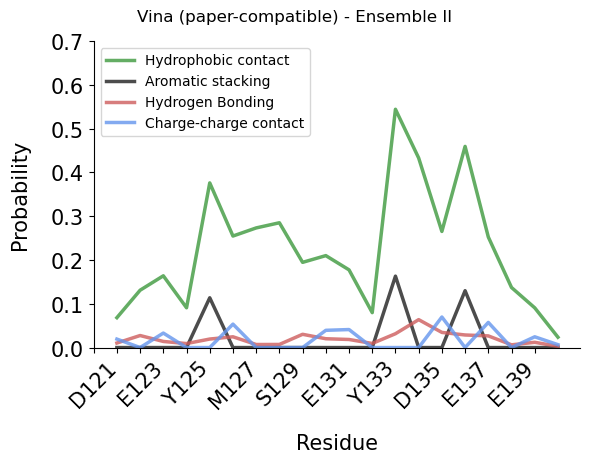

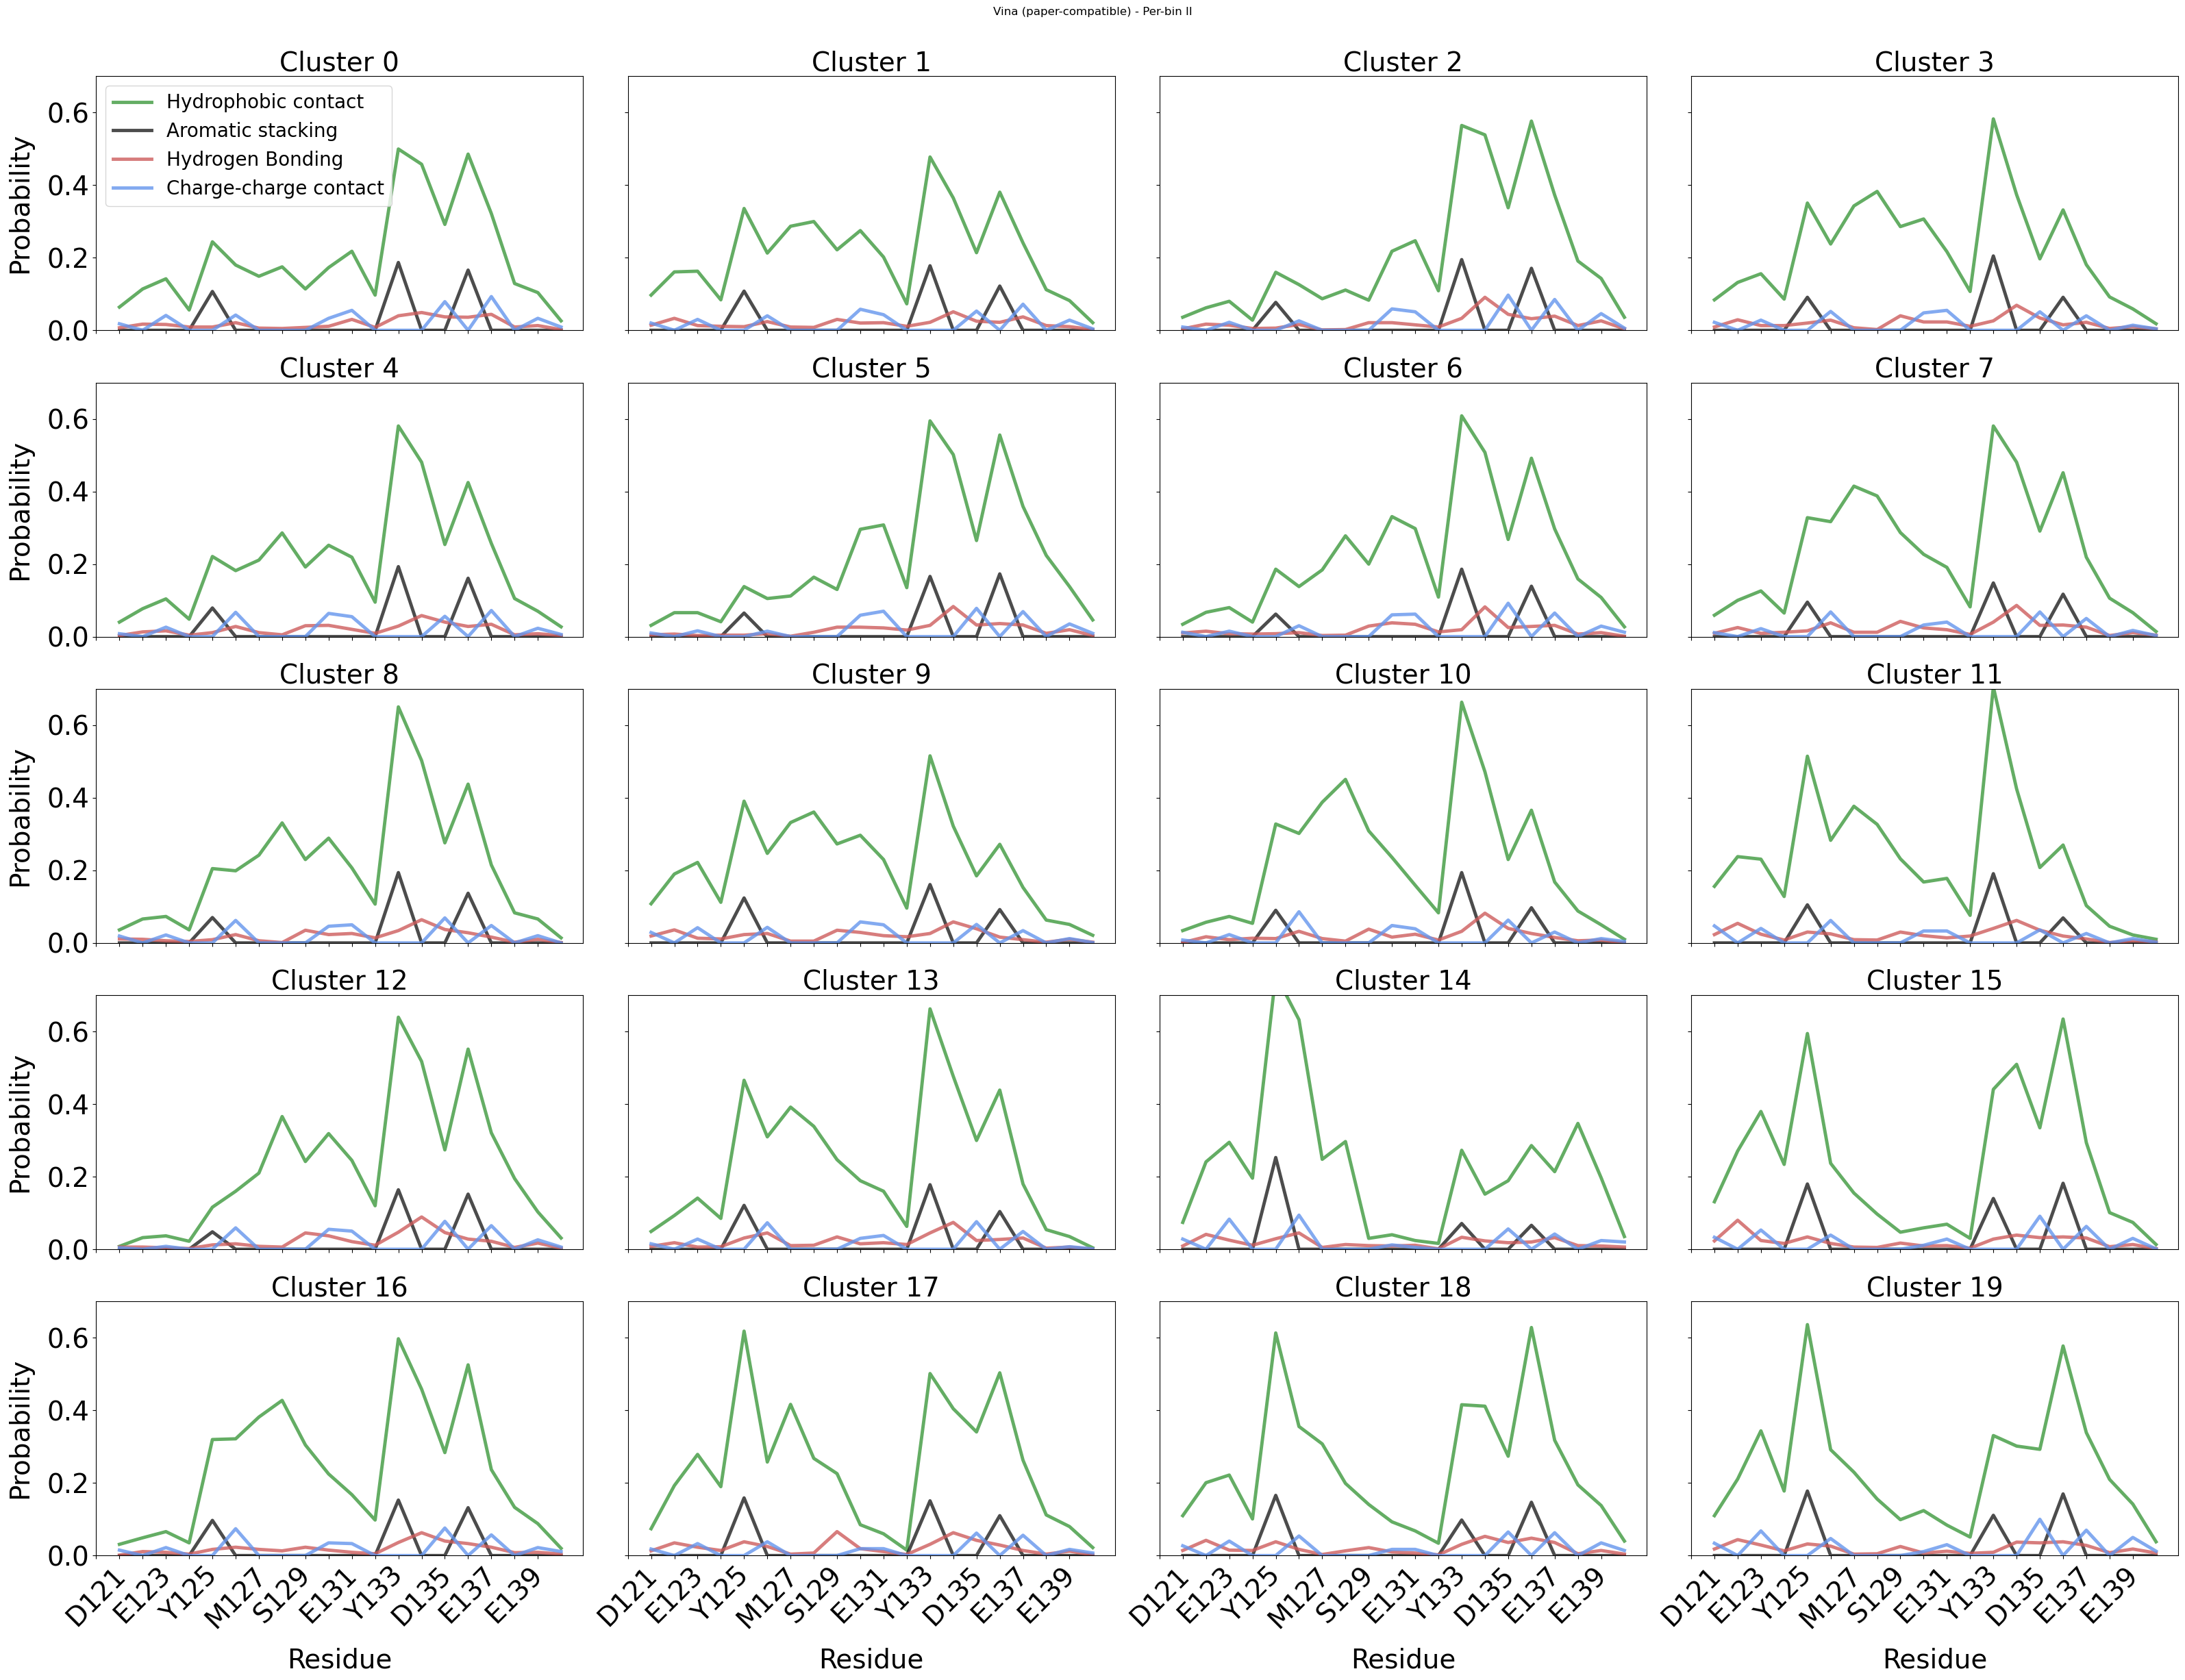

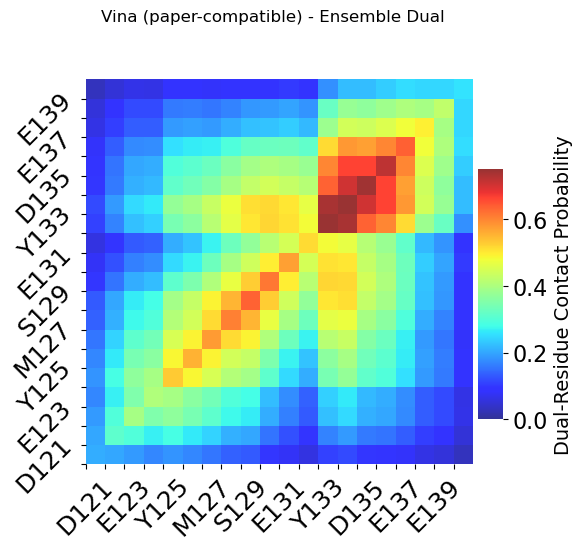

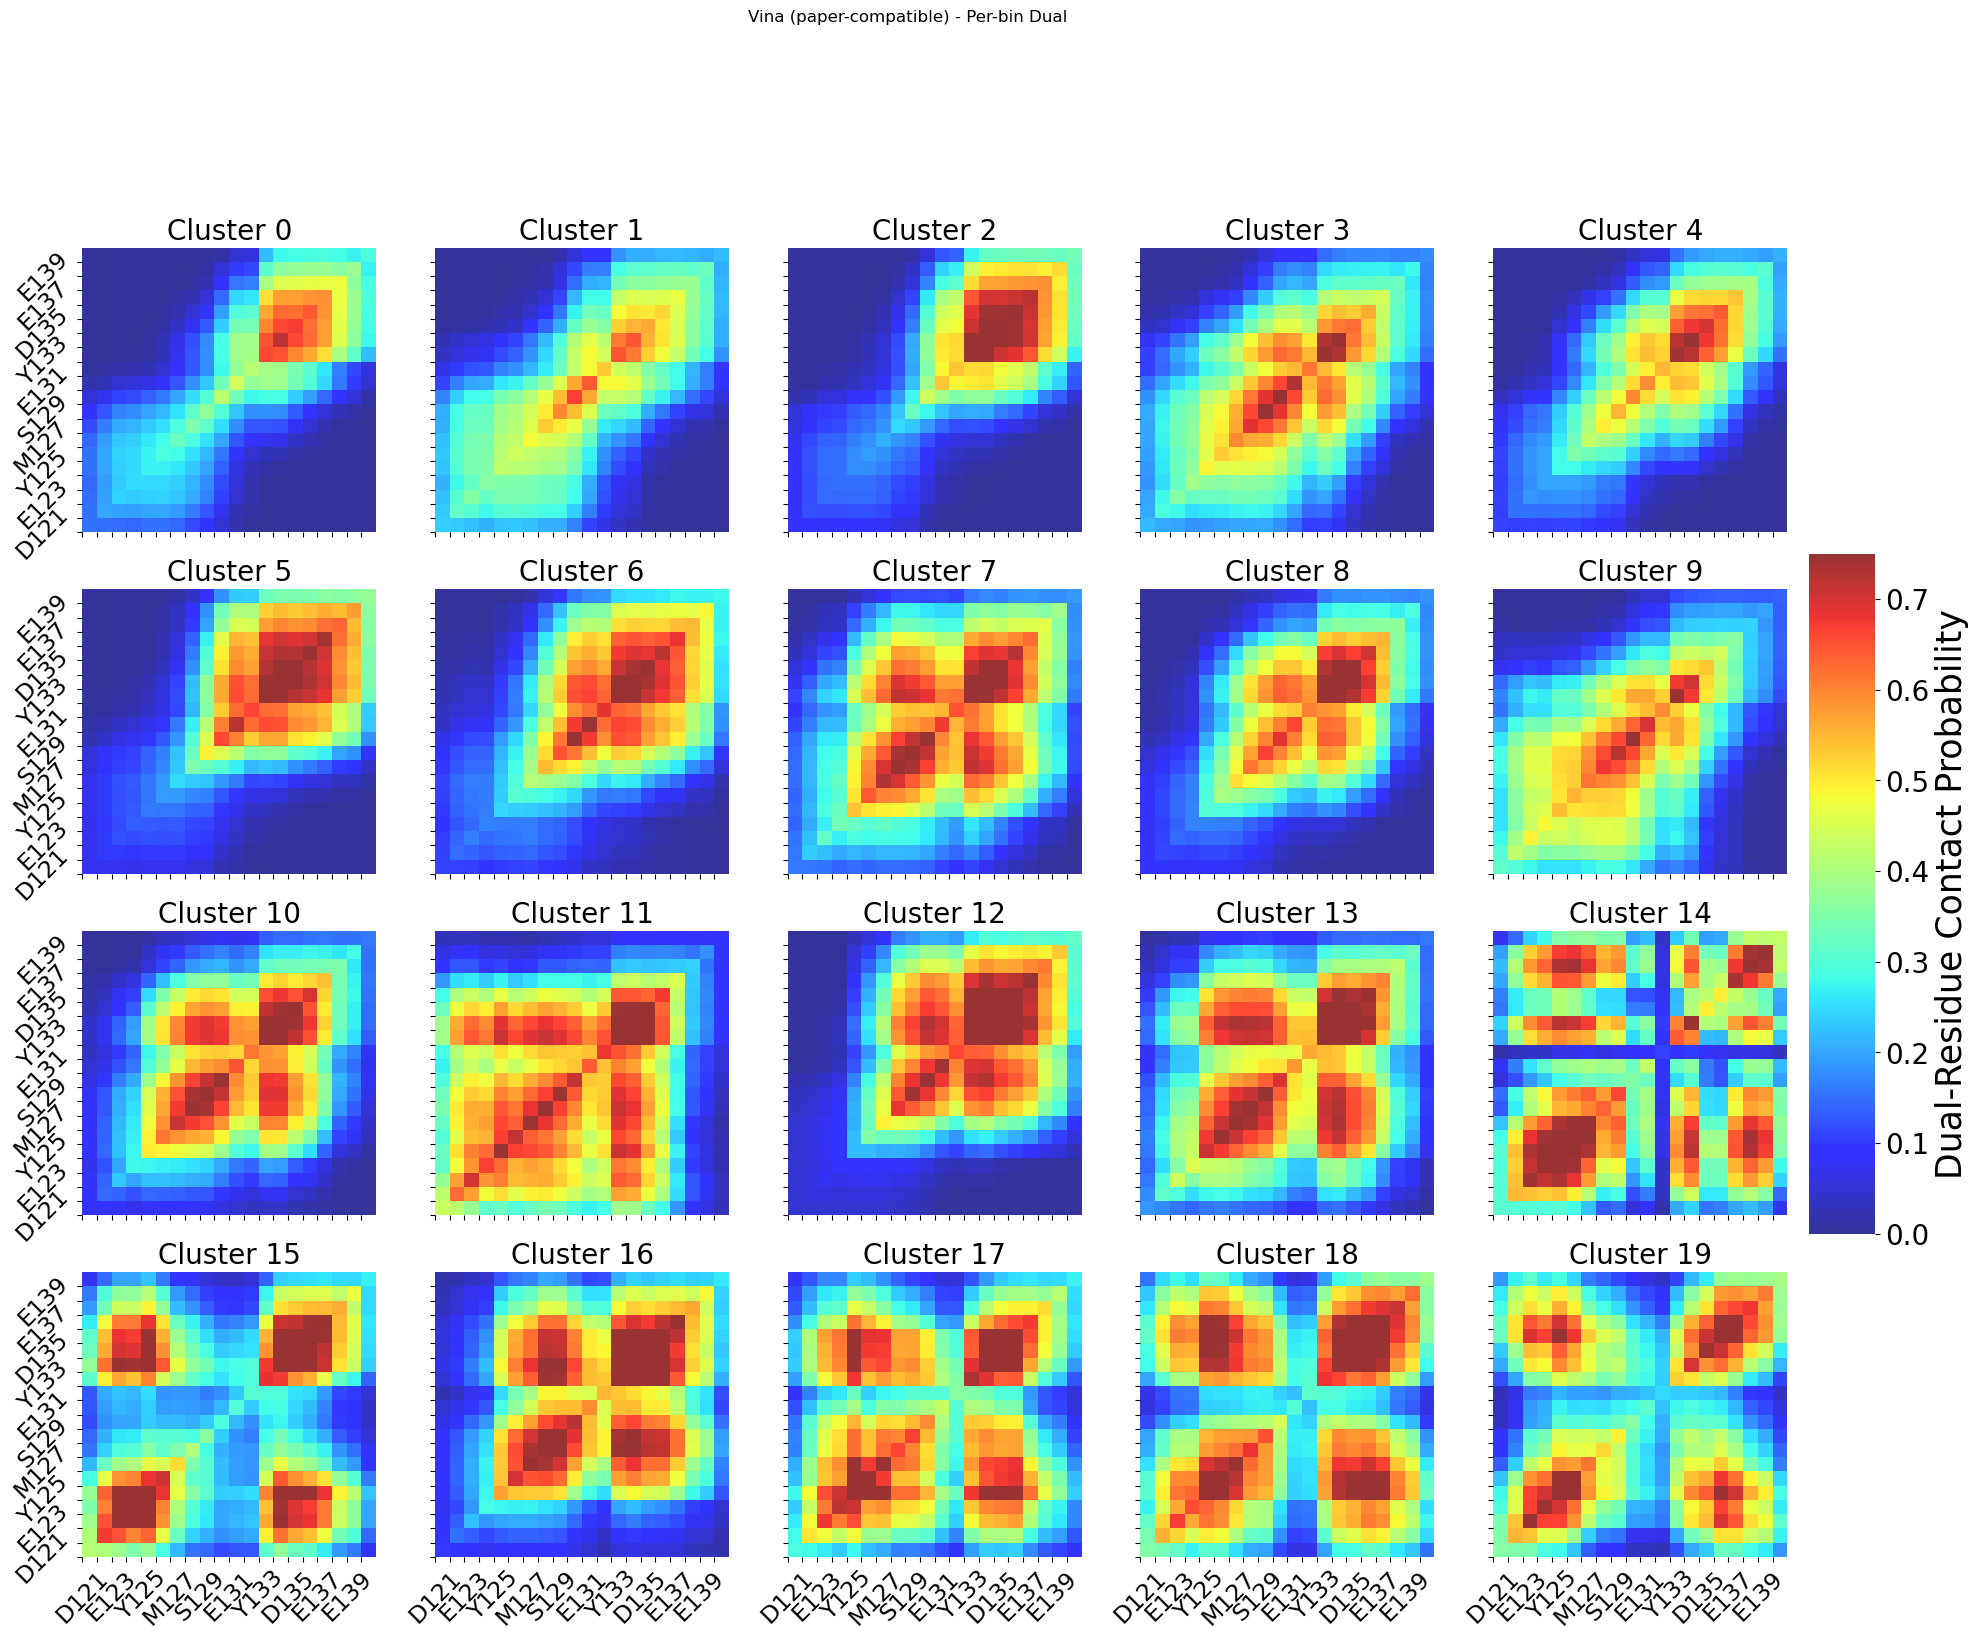


All outputs in: /home/zhihanz/data/autodock_vina/analysis_paper_compatible

Expected results:
  - hphob  : ~3-5 (similar to before)
  - aro    : ~0.5-1.5
  - hbond  : ~0.3-0.6  ← should be MUCH higher than 0.005 now
  - charge : ~0.1-0.3


In [1]:
# ================================================================
# 7.  Interaction fingerprints with PAPER PDB indices
# ================================================================
if HAS_DOCKING_TOOLS:
    print("\n" + "=" * 70)
    print("STEP 5 - Interaction fingerprints (paper-style)")
    print("=" * 70)

    # Split into 20 equal time bins (mimics paper's 20 t-SNE clusters)
    N_BINS = 20
    bin_size = vina_traj.n_frames // N_BINS
    bin_trajs = [vina_traj[i*bin_size:(i+1)*bin_size] for i in range(N_BINS)]
    bin_pop = np.ones(N_BINS) / N_BINS

    contacts = {'hphob': [], 'aro': [], 'hbond': [], 'charge': [], 'dual': []}

    for i, traj in enumerate(bin_trajs):
        print(f"Bin {i+1:>2}: {traj.n_frames} frames", end=" | ")

        try:
            hp = trajectory_analysis.hphob_contacts(traj, LIGAND_RESID_PAPER)
            contacts['hphob'].append(hp)
            print(f"hphob={hp.mean(axis=0).sum():.3f}", end=" | ")
        except Exception as e:
            print(f"hphob ERR:{e}", end=" | ")
            contacts['hphob'].append(np.zeros((traj.n_frames, 20)))

        try:
            # Use the actual benzene + 5-ring detected from geometry
            ar = trajectory_analysis.aro_contacts(
                traj, ligand_rings=[RING_BENZENE_PAPER])  # ONLY benzene is aromatic
            contacts['aro'].append(ar)
            print(f"aro={ar.mean(axis=0).sum():.3f}", end=" | ")
        except Exception as e:
            print(f"aro ERR:{e}", end=" | ")
            contacts['aro'].append(np.zeros((traj.n_frames, 20)))

        try:
            # Use the actual NH2 N-H pairs from geometry
            hb = trajectory_analysis.hbond(
                traj, LIGAND_RESID_PAPER, lig_hbond_donors=LIG_HBOND_DONORS_PAPER)
            contacts['hbond'].append(hb)
            print(f"hbond={hb.mean(axis=0).sum():.3f}", end=" | ")
        except Exception as e:
            print(f"hbond ERR:{e}", end=" | ")
            contacts['hbond'].append(np.zeros((traj.n_frames, 20)))

        try:
            # Use NH2 N (312) as positive charge - chemically correct
            ch = trajectory_analysis.charge_contacts(
                traj, Ligand_Pos_Charges=LIG_POS_CHARGES_PAPER)
            contacts['charge'].append(ch)
            print(f"charge={ch.mean(axis=0).sum():.3f}", end=" | ")
        except Exception as e:
            print(f"charge ERR:{e}", end=" | ")
            contacts['charge'].append(np.zeros((traj.n_frames, 20)))

        try:
            du = trajectory_analysis.dual_contact(traj, residue_idx=LIGAND_RESID_PAPER)
            contacts['dual'].append(du)
        except Exception as e:
            contacts['dual'].append(None)
        print()

    # Reshape for plotting
    contacts_plot = {}
    for key in ['hphob', 'aro', 'hbond', 'charge']:
        per_bin_means = [arr[:, :20].mean(axis=0) if arr is not None
                         else np.zeros(20) for arr in contacts[key]]
        contacts_plot[key] = np.array(per_bin_means)[:, np.newaxis, :]

    dual_v = [d for d in contacts['dual'] if d is not None]
    if dual_v:
        ds = dual_v[0].shape
        contacts_plot['dual'] = np.stack([
            d if d is not None else np.zeros(ds) for d in contacts['dual']])

    # Plots
    plotting.plot_ensemble_ii(contacts_plot, bin_pop[:, np.newaxis])
    plt.suptitle('Vina (paper-compatible) - Ensemble II', y=1.02)
    plt.savefig(OUT_DIR / 'ensemble_ii_vina.png', dpi=150, bbox_inches='tight')
    plt.show()

    plotting.plot_clus_ii(contacts_plot)
    plt.suptitle('Vina (paper-compatible) - Per-bin II', y=1.02)
    plt.savefig(OUT_DIR / 'clus_ii_vina.png', dpi=150, bbox_inches='tight')
    plt.show()

    if 'dual' in contacts_plot:
        plotting.plot_ensemble_dual(contacts_plot['dual'], bin_pop)
        plt.suptitle('Vina (paper-compatible) - Ensemble Dual', y=1.02)
        plt.savefig(OUT_DIR / 'ensemble_dual_vina.png', dpi=150, bbox_inches='tight')
        plt.show()

        plotting.plot_clus_dual(contacts_plot['dual'])
        plt.suptitle('Vina (paper-compatible) - Per-bin Dual', y=1.02)
        plt.savefig(OUT_DIR / 'clus_dual_vina.png', dpi=150, bbox_inches='tight')
        plt.show()


# Save results
np.savez(OUT_DIR / 'vina_results.npz',
         frame_ids=vina_frame_ids, scores=vina_scores,
         bound_fraction=bf_vina_ensemble[:20])

master = pd.DataFrame({'frame_id': vina_frame_ids, 'vina_score': vina_scores})
master.to_csv(OUT_DIR / 'master_vina_47.csv', index=False)

print(f"\nAll outputs in: {OUT_DIR}")
print("\nExpected results:")
print("  - hphob  : ~3-5 (similar to before)")
print("  - aro    : ~0.5-1.5")
print("  - hbond  : ~0.3-0.6  ← should be MUCH higher than 0.005 now")
print("  - charge : ~0.1-0.3")

In [3]:
"""
Best-matched RMSD: AutoDock Vina (non-GPU, Ligand 47) vs 完整 t-SNE MD ensemble.
每帧 input = frame_NNNNN_47_best_out.pdbqt (一帧一个 best pose).
配体原子映射: Vina PDBQT 顺序 → MD 47bf 顺序, permutation 已通过键长几何验证.
论文协议: Cα 对齐, 完整 ensemble.
"""
import os, re, glob, time
import numpy as np
import mdtraj as md

# ---------------------------------------------------------------- paths
VINA_RESULTS_DIR  = '/home/zhihanz/data/autodock_vina/hpc_results/05042026/docking_best_47'
VINA_FILE_PATTERN = "frame_*_47_best_out.pdbqt"
PROT_FRAMES_DIR   = '/home/zhihanz/data/autodock_vina/protein_frames/protein_frames_apo'

MD_DIR     = '/home/zhihanz/data/selected_mdtrajs/TSNE_CLUSTER_XTC/47bf_selections'
MD_TOP_PDB = os.path.join(MD_DIR, '47bf.pdb')

OUT_NPZ = '/home/zhihanz/data/vina_best_matched_rmsd_L47_FINAL.npz'

# ---------------------------------------------------------------- constants
# Vina PDBQT heavy 顺序 → MD 47bf 配体重原子顺序 (已键长验证)
VINA_TO_MD = np.array(
    [10, 8, 9, 7, 11, 12, 5, 6, 13, 14, 3, 4, 0, 1, 2, 15, 21, 20, 19, 18, 17, 16])

HYDROGEN_TYPES = {'HD', 'H'}
FNAME_RE = re.compile(r"frame_(\d+)_47_best_out\.pdbqt$")

# ---------------------------------------------------------------- load MD ensemble
print('Loading t-SNE clustered XTCs ...')
xtc_files = []
for x in sorted(glob.glob(os.path.join(MD_DIR, 'c_*.xtc'))):
    name = os.path.basename(x)
    if re.fullmatch(r'c_\d+\.xtc', name) or re.fullmatch(r'c_16_\d\.xtc', name):
        xtc_files.append(x)
print(f'  XTC files: {len(xtc_files)}')

md_top  = md.load(MD_TOP_PDB)
md_traj = md.join([md.load(x, top=md_top.top) for x in xtc_files])
print(f'  total MD frames: {md_traj.n_frames}')

d_ca = md_traj.top.select('protein and name CA')
d_lig_heavy = np.array([
    a.index for a in md_traj.top.atoms
    if a.residue.name == '<1>' and a.element.symbol != 'H'
])
print(f'  MD Cα: {len(d_ca)}, ligand heavy: {len(d_lig_heavy)}')

# ---------------------------------------------------------------- parse Vina pdbqt
def parse_vina_pdbqt(filepath):
    m = FNAME_RE.search(os.path.basename(filepath))
    if not m: return None
    frame_id = int(m.group(1))

    with open(filepath) as fh:
        lines = fh.readlines()

    has_model = any(line.startswith("MODEL") for line in lines)
    coords_heavy = []
    score = None
    in_first_model = not has_model
    seen_first_score = False

    for line in lines:
        if has_model:
            if line.startswith("MODEL"):
                in_first_model = (line.strip().split()[-1] == "1")
                continue
            if line.startswith("ENDMDL"):
                if in_first_model: break
                continue
            if not in_first_model: continue

        if line.startswith("REMARK VINA RESULT:") and not seen_first_score:
            try:
                score = float(line.split()[3]); seen_first_score = True
            except (IndexError, ValueError): pass
        elif line.startswith(("ATOM", "HETATM")):
            atom_type = line.split()[-1].strip()
            try:
                xyz = [float(line[30:38]), float(line[38:46]), float(line[46:54])]
            except (ValueError, IndexError):
                continue
            if atom_type not in HYDROGEN_TYPES:
                coords_heavy.append(xyz)

    return (frame_id, score, np.array(coords_heavy))

print('\nParsing Vina pdbqt files ...')
pdbqt_files = sorted(glob.glob(os.path.join(VINA_RESULTS_DIR, VINA_FILE_PATTERN)))
print(f'  found {len(pdbqt_files)} files')

records = []   # (frame_id, score, heavy_md_order)
n_failed = 0
for fp in pdbqt_files:
    try:
        parsed = parse_vina_pdbqt(fp)
        if parsed is None: n_failed += 1; continue
        fid, score, heavy_vina = parsed
        if score is None or len(heavy_vina) != 22:
            n_failed += 1; continue
        heavy_md = heavy_vina[VINA_TO_MD]   # Vina 顺序 → MD 顺序
        records.append((fid, score, heavy_md))
    except Exception:
        n_failed += 1

print(f'  valid records: {len(records)}, failed: {n_failed}')

# ---------------------------------------------------------------- 匹配 protein PDB
def fast_ca_coords(pdb_path):
    coords = []
    with open(pdb_path) as f:
        for line in f:
            if line.startswith('ATOM') and line[12:16].strip() == 'CA':
                coords.append((float(line[30:38]),
                               float(line[38:46]),
                               float(line[46:54])))
    return np.array(coords) / 10.0   # Å → nm

records_with_pdb = []
n_missing_pdb = 0
for fid, score, heavy_md in records:
    pdb = os.path.join(PROT_FRAMES_DIR, f'protein_only_frame_{fid:05d}_fasudil_apo.pdb')
    if not os.path.exists(pdb):
        n_missing_pdb += 1; continue
    records_with_pdb.append((fid, score, heavy_md, pdb))
records = records_with_pdb
print(f'  with matching PDB: {len(records)} (missing: {n_missing_pdb})')

n_ca_pdb = len(fast_ca_coords(records[0][3]))
print(f'  PDB Cα atoms: {n_ca_pdb}')
if n_ca_pdb != len(d_ca):
    raise RuntimeError(f'Cα count mismatch: PDB={n_ca_pdb}, MD={len(d_ca)}')

print('Extracting Cα + ligand coords ...')
n_poses = len(records)
all_pose_ca       = np.zeros((n_poses, n_ca_pdb, 3), dtype=np.float32)
pose_lig_xyz_all  = np.zeros((n_poses, 22, 3), dtype=np.float32)
frame_ids         = np.zeros(n_poses, dtype=int)
vina_scores       = np.zeros(n_poses, dtype=float)

t0 = time.time()
for i, (fid, score, heavy_md, pdb) in enumerate(records):
    all_pose_ca[i] = fast_ca_coords(pdb)
    pose_lig_xyz_all[i] = heavy_md / 10.0   # Å → nm
    frame_ids[i] = fid
    vina_scores[i] = score
    if (i+1) % 2000 == 0:
        print(f'  {i+1}/{n_poses}  elapsed={time.time()-t0:.1f}s')
print(f'  Loaded all {n_poses} in {time.time()-t0:.1f}s')

# ---------------------------------------------------------------- batched Kabsch
def batch_kabsch_align_apply(mobile_ca, target_ca, mobile_lig):
    n, k, _ = mobile_ca.shape
    mu1 = mobile_ca.mean(axis=1)
    mu2 = target_ca.mean(axis=0)
    mobile_c = mobile_ca - mu1[:, None, :]
    target_c = target_ca - mu2[None, :]
    correlation = np.einsum('nki,kj->nij', mobile_c, target_c)
    V, S, W_tr = np.linalg.svd(correlation)
    is_reflection = (np.linalg.det(V) * np.linalg.det(W_tr)) < 0.0
    V_corrected = V.copy()
    V_corrected[is_reflection, :, -1] *= -1
    rotation = np.einsum('nij,njk->nik', V_corrected, W_tr)
    mu1_rot = np.einsum('ni,nij->nj', mu1, rotation)
    translation = mu2[None, :] - mu1_rot
    aligned = np.einsum('nmj,njk->nmk', mobile_lig, rotation) + translation[:, None, :]
    return aligned

# ---------------------------------------------------------------- best-matched RMSD
md_ca_xyz  = md_traj.xyz[:, d_ca, :].copy()
md_lig_xyz = md_traj.xyz[:, d_lig_heavy, :].copy()
n_lig = md_lig_xyz.shape[1]
print(f'\nmd_ca_xyz: {md_ca_xyz.shape}, md_lig_xyz: {md_lig_xyz.shape}')

print('Computing best-matched RMSD ...')
best_rmsd      = np.full(n_poses, np.nan)
best_match_idx = np.full(n_poses, -1, dtype=int)

t0 = time.time()
for i in range(n_poses):
    pose_ca_xyz  = all_pose_ca[i]
    pose_lig_xyz = pose_lig_xyz_all[i]

    aligned_lig = batch_kabsch_align_apply(md_ca_xyz, pose_ca_xyz, md_lig_xyz)
    diff = aligned_lig - pose_lig_xyz[None, :, :]
    rmsd_per_frame = np.sqrt((diff**2).sum(axis=(1, 2)) / n_lig)

    j = int(rmsd_per_frame.argmin())
    best_rmsd[i] = rmsd_per_frame[j] * 10.0   # nm → Å
    best_match_idx[i] = j

    if (i+1) % 500 == 0:
        dt  = time.time() - t0
        eta = dt * (n_poses - (i+1)) / (i+1)
        print(f'  {i+1}/{n_poses}  best={best_rmsd[i]:.2f} Å  '
              f'elapsed={dt:.1f}s  eta={eta:.1f}s')
print(f'Total RMSD time: {time.time()-t0:.1f}s')

# ---------------------------------------------------------------- save & summarize
np.savez(OUT_NPZ,
         rmsd_A=best_rmsd,
         frame_idx=frame_ids,
         vina_score=vina_scores,
         best_match_md_idx=best_match_idx)
print(f'Saved → {OUT_NPZ}')

v = best_rmsd[~np.isnan(best_rmsd)]
print(f'\nSummary (n={len(v)}):')
print(f'  median: {np.median(v):.2f} Å   mean: {v.mean():.2f} Å')
print(f'  <3 Å:   {(v<3).mean()*100:.2f}%   (paper Vina apo: 16.69%)')
print(f'  <5 Å:   {(v<5).mean()*100:.2f}%   (paper Vina apo: 97.11%)')

Loading t-SNE clustered XTCs ...
  XTC files: 28
  total MD frames: 21021
  MD Cα: 20, ligand heavy: 22

Parsing Vina pdbqt files ...
  found 20020 files
  valid records: 20020, failed: 0
  with matching PDB: 20020 (missing: 0)
  PDB Cα atoms: 20
Extracting Cα + ligand coords ...
  2000/20020  elapsed=0.2s
  4000/20020  elapsed=0.3s
  6000/20020  elapsed=0.5s
  8000/20020  elapsed=0.7s
  10000/20020  elapsed=0.8s
  12000/20020  elapsed=1.0s
  14000/20020  elapsed=1.1s
  16000/20020  elapsed=1.3s
  18000/20020  elapsed=1.5s
  20000/20020  elapsed=1.6s
  Loaded all 20020 in 1.6s

md_ca_xyz: (21021, 20, 3), md_lig_xyz: (21021, 22, 3)
Computing best-matched RMSD ...
  500/20020  best=2.40 Å  elapsed=45.3s  eta=1768.7s
  1000/20020  best=2.57 Å  elapsed=90.6s  eta=1723.0s
  1500/20020  best=2.61 Å  elapsed=135.9s  eta=1677.8s
  2000/20020  best=2.35 Å  elapsed=181.1s  eta=1631.8s
  2500/20020  best=1.90 Å  elapsed=226.1s  eta=1584.5s
  3000/20020  best=2.72 Å  elapsed=271.2s  eta=1538.4s
  